In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# CARGA DEL DATOS

In [2]:
DB_PATH = '../data/movielens.db' 

In [3]:
print(" PROYECTO MOVIELENS 100K")

#  CONECTAR 
print(f"\n Conectando a: {DB_PATH}")
conn = sqlite3.connect(DB_PATH)

#  CARGAR TABLAS 

ratings = pd.read_sql("SELECT * FROM ratings", conn)
ratings.columns = ['userId', 'movieId', 'rating', 'timestamp']
print(f" Ratings: {len(ratings):,} filas")

users = pd.read_sql("SELECT * FROM users", conn)
users.columns = ['userId', 'age', 'gender', 'occupation', 'zipcode']
print(f" Users: {len(users):,} filas")

movies = pd.read_sql("SELECT * FROM items", conn)
movies.rename(columns={'item_id': 'movieId'}, inplace=True)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
print(f" Movies: {len(movies):,} filas")

conn.close()



 PROYECTO MOVIELENS 100K

 Conectando a: ../data/movielens.db
 Ratings: 100,000 filas
 Users: 943 filas
 Movies: 1,682 filas


# COMBINANDO DATASETS

In [4]:
df = ratings.merge(users, on='userId', how='left')
df = df.merge(movies, on='movieId', how='left')

print(f" Dataset completo: {len(df):,} filas, {len(df.columns)} columnas")


 Dataset completo: 100,000 filas, 32 columnas


In [5]:
print(" ESTADÍSTICAS")
print(f"Total ratings: {len(df):,}")
print(f"Usuarios únicos: {df['userId'].nunique():,}")
print(f"Películas únicas: {df['movieId'].nunique():,}")
print(f"Rating promedio: {df['rating'].mean():.2f}/5")
print(f"Años: {df['year'].min():.0f} - {df['year'].max():.0f}")

 ESTADÍSTICAS
Total ratings: 100,000
Usuarios únicos: 943
Películas únicas: 1,682
Rating promedio: 3.53/5
Años: 1922 - 1998


# EDA NIKITA

---

## 1. Análisis Temporal (Evolución por Década)

In [6]:
# ── 1.1 Preparar columna de década ──────────────────────────────────────────
df['decade'] = (df['year'] // 10 * 10).astype('Int64')

# Número de películas únicas por década
movies_per_decade = df.drop_duplicates('movieId').groupby('decade').size().reset_index(name='num_movies')

# Número de ratings por década
ratings_per_decade = df.groupby('decade').size().reset_index(name='num_ratings')

# Rating promedio por década
avg_rating_decade = df.groupby('decade')['rating'].mean().reset_index(name='avg_rating')

# Combinar en un solo DataFrame resumen
decade_summary = movies_per_decade.merge(ratings_per_decade, on='decade').merge(avg_rating_decade, on='decade')
decade_summary['avg_rating'] = decade_summary['avg_rating'].round(2)
print(decade_summary.to_string(index=False))

 decade  num_movies  num_ratings  avg_rating
   1920           2           56        3.54
   1930          29         1496        3.93
   1940          45         2249        4.01
   1950          57         3527        3.94
   1960          46         3909        3.88
   1970          55         6448        3.87
   1980         110        12834        3.77
   1990        1337        69472        3.39


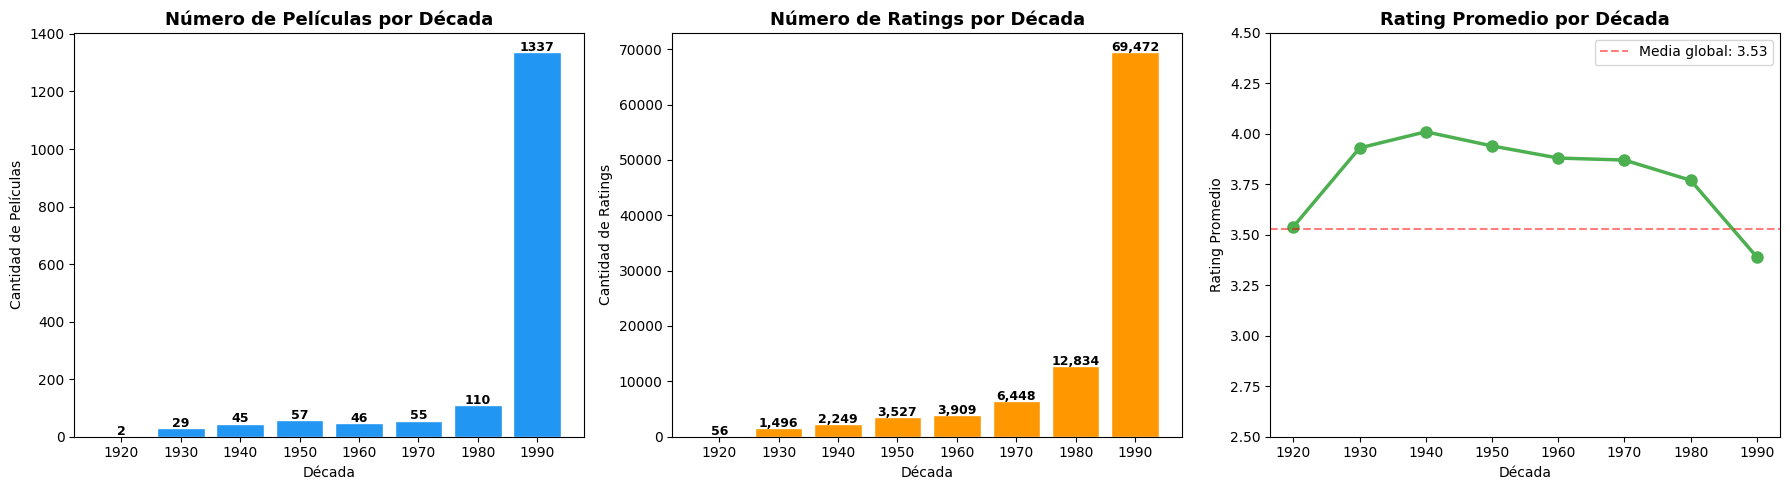

In [7]:
# ── 1.2 Visualización: Películas y Rating promedio por década ────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Número de películas por década
axes[0].bar(decade_summary['decade'].astype(str), decade_summary['num_movies'], color='#2196F3', edgecolor='white')
axes[0].set_title('Número de Películas por Década', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Década')
axes[0].set_ylabel('Cantidad de Películas')
for i, v in enumerate(decade_summary['num_movies']):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=9)

# Gráfico 2: Número de ratings por década
axes[1].bar(decade_summary['decade'].astype(str), decade_summary['num_ratings'], color='#FF9800', edgecolor='white')
axes[1].set_title('Número de Ratings por Década', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Cantidad de Ratings')
for i, v in enumerate(decade_summary['num_ratings']):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Gráfico 3: Rating promedio por década
axes[2].plot(decade_summary['decade'].astype(str), decade_summary['avg_rating'], 
             marker='o', linewidth=2.5, color='#4CAF50', markersize=8)
axes[2].set_title('Rating Promedio por Década', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Década')
axes[2].set_ylabel('Rating Promedio')
axes[2].set_ylim(2.5, 4.5)
axes[2].axhline(y=df['rating'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Media global: {df["rating"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
# ── 1.3 Top 10 películas mejor valoradas por década ─────────────────────────
top_by_decade = (
    df.groupby(['decade', 'movieId', 'title'])
    .agg(avg_rating=('rating', 'mean'), num_ratings=('rating', 'count'))
    .reset_index()
    .query('num_ratings >= 20')  # Mínimo 20 ratings para ser representativa
    .sort_values(['decade', 'avg_rating'], ascending=[True, False])
    .groupby('decade')
    .head(3)
)

print("  TOP 3 PELÍCULAS POR DÉCADA (mín. 20 ratings):\n")
for decade, group in top_by_decade.groupby('decade'):
    print(f"  Década {decade}s:")
    for _, row in group.iterrows():
        print(f"    {row['title']} → ★ {row['avg_rating']:.2f} ({row['num_ratings']} ratings)")
    print()

  TOP 3 PELÍCULAS POR DÉCADA (mín. 20 ratings):

  Década 1920s:
    Nosferatu (Nosferatu, eine Symphonie des Grauens) (1922) → ★ 3.56 (54 ratings)

  Década 1930s:
    Thin Man, The (1934) → ★ 4.15 (60 ratings)
    Mr. Smith Goes to Washington (1939) → ★ 4.12 (105 ratings)
    Wizard of Oz, The (1939) → ★ 4.08 (246 ratings)

  Década 1940s:
    Casablanca (1942) → ★ 4.46 (243 ratings)
    Third Man, The (1949) → ★ 4.33 (72 ratings)
    Citizen Kane (1941) → ★ 4.29 (198 ratings)

  Década 1950s:
    Rear Window (1954) → ★ 4.39 (209 ratings)
    12 Angry Men (1957) → ★ 4.34 (125 ratings)
    North by Northwest (1959) → ★ 4.28 (179 ratings)

  Década 1960s:
    To Kill a Mockingbird (1962) → ★ 4.29 (219 ratings)
    Manchurian Candidate, The (1962) → ★ 4.26 (131 ratings)
    Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963) → ★ 4.25 (194 ratings)

  Década 1970s:
    Star Wars (1977) → ★ 4.36 (583 ratings)
    One Flew Over the Cuckoo's Nest (1975) → ★ 4.29 (264

## 2. Análisis por Género de Película

In [9]:
# ── 2.1 Definir columnas de género y calcular estadísticas ──────────────────
genre_cols = [
    'unknown', 'Action', 'Adventure', 'Animation', 'Childrens',
    'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
    'Film_Noir', 'Horror', 'Musical', 'Mystery', 'Romance',
    'Sci_Fi', 'Thriller', 'War', 'Western'
]

# Calcular: total de películas, total de ratings y rating promedio por género
genre_stats = []
for g in genre_cols:
    if g in df.columns:
        subset = df[df[g] == 1]
        genre_stats.append({
            'genre': g,
            'num_movies': subset['movieId'].nunique(),
            'num_ratings': len(subset),
            'avg_rating': round(subset['rating'].mean(), 2)
        })

genre_df = pd.DataFrame(genre_stats).sort_values('num_ratings', ascending=False)
print(genre_df.to_string(index=False))

      genre  num_movies  num_ratings  avg_rating
      Drama         725        39895        3.69
     Comedy         505        29832        3.39
     Action         251        25589        3.48
   Thriller         251        21872        3.51
    Romance         247        19461        3.62
  Adventure         135        13753        3.50
     Sci_Fi         101        12730        3.56
        War          71         9398        3.82
      Crime         109         8055        3.63
  Childrens         122         7182        3.35
     Horror          92         5317        3.29
    Mystery          61         5245        3.64
    Musical          56         4954        3.52
  Animation          42         3605        3.58
    Western          27         1854        3.61
  Film_Noir          24         1733        3.92
    Fantasy          22         1352        3.22
Documentary          50          758        3.67
    unknown           2           10        3.20


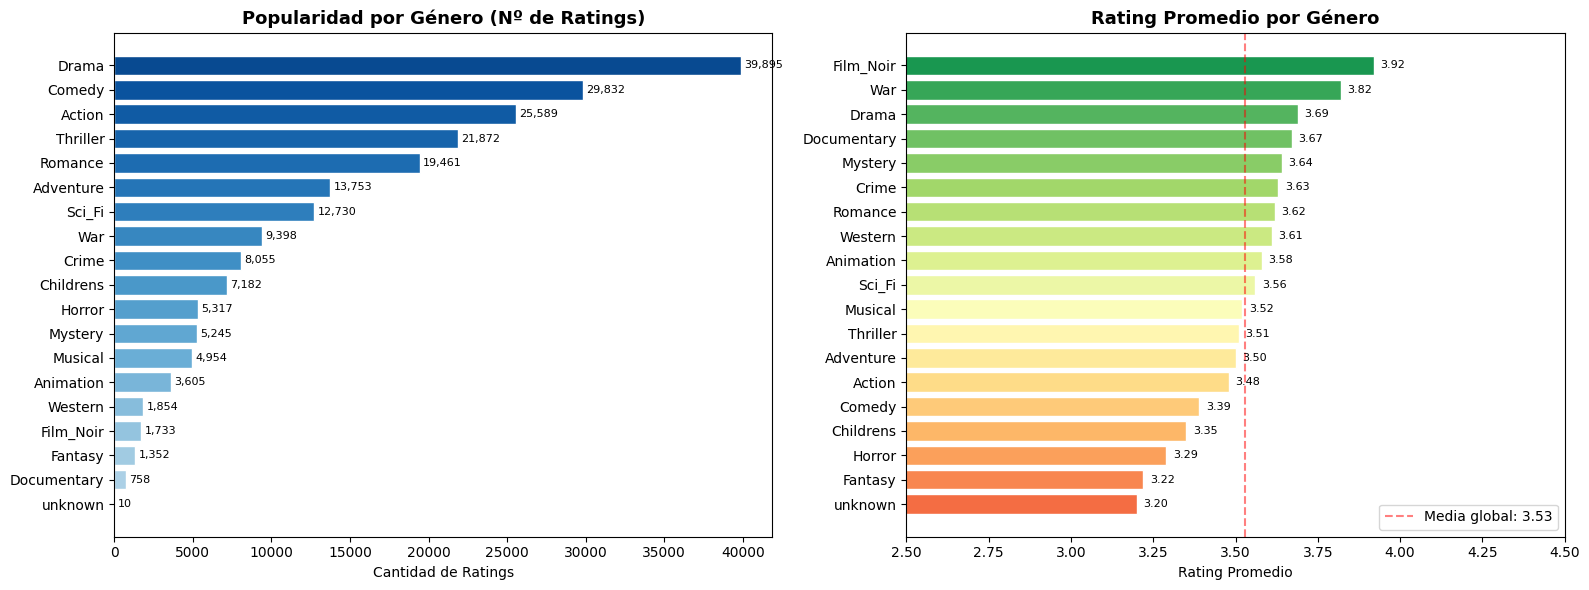

In [10]:
# ── 2.2 Visualización: Ratings y popularidad por género ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Número de ratings por género (horizontal)
genre_sorted = genre_df.sort_values('num_ratings')
colors_pop = plt.cm.Blues(np.linspace(0.3, 0.9, len(genre_sorted)))
axes[0].barh(genre_sorted['genre'], genre_sorted['num_ratings'], color=colors_pop, edgecolor='white')
axes[0].set_title('Popularidad por Género (Nº de Ratings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Ratings')
for i, v in enumerate(genre_sorted['num_ratings']):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=8)

# Gráfico 2: Rating promedio por género (horizontal)
genre_sorted_rating = genre_df.sort_values('avg_rating')
colors_rat = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(genre_sorted_rating)))
axes[1].barh(genre_sorted_rating['genre'], genre_sorted_rating['avg_rating'], color=colors_rat, edgecolor='white')
axes[1].set_title('Rating Promedio por Género', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating Promedio')
axes[1].set_xlim(2.5, 4.5)
axes[1].axvline(x=df['rating'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Media global: {df["rating"].mean():.2f}')
axes[1].legend()
for i, v in enumerate(genre_sorted_rating['avg_rating']):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

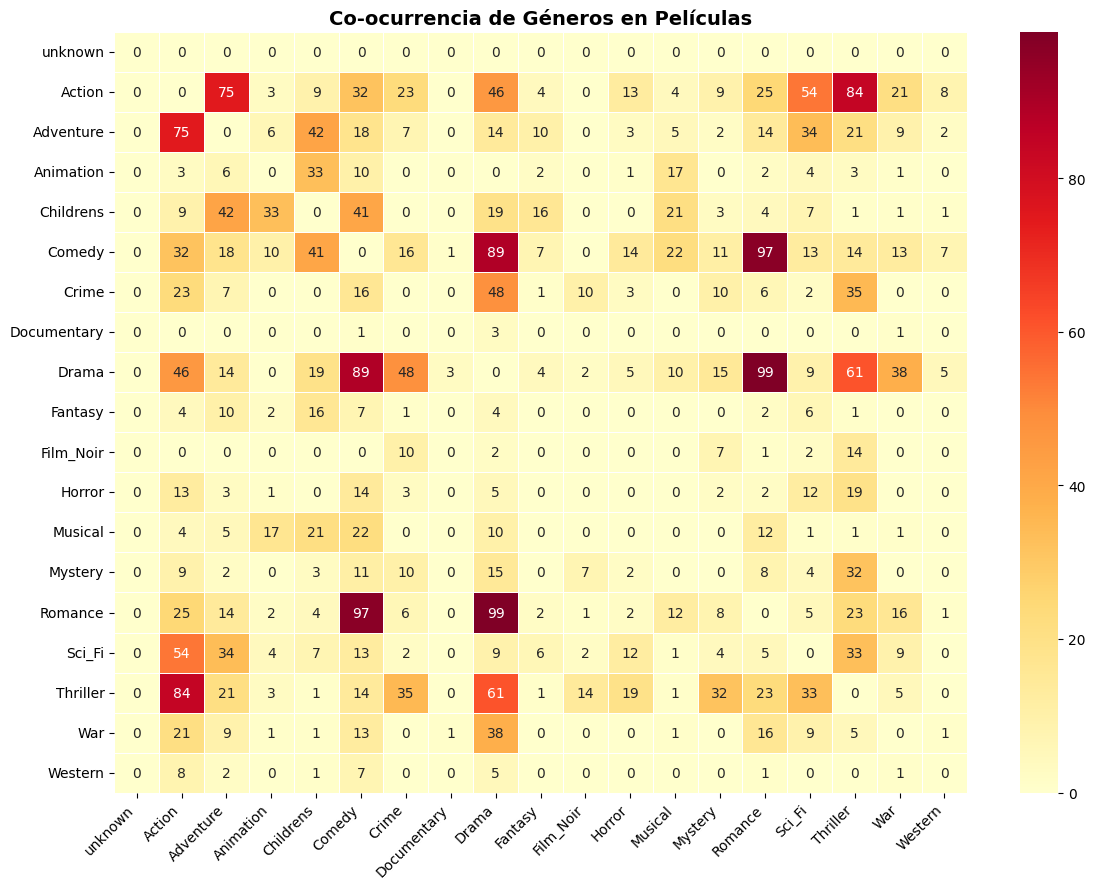

In [11]:
# ── 2.3 Heatmap: Co-ocurrencia de géneros ────────────────────────────────────
# ¿Qué géneros se combinan más frecuentemente en las mismas películas?
movies_unique = df.drop_duplicates('movieId')
genre_matrix = movies_unique[genre_cols].astype(int)
co_occurrence = genre_matrix.T.dot(genre_matrix)

# Normalizar para mejor visualización
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(12, 9))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=genre_cols, yticklabels=genre_cols,
            linewidths=0.5, linecolor='white')
plt.title('Co-ocurrencia de Géneros en Películas', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

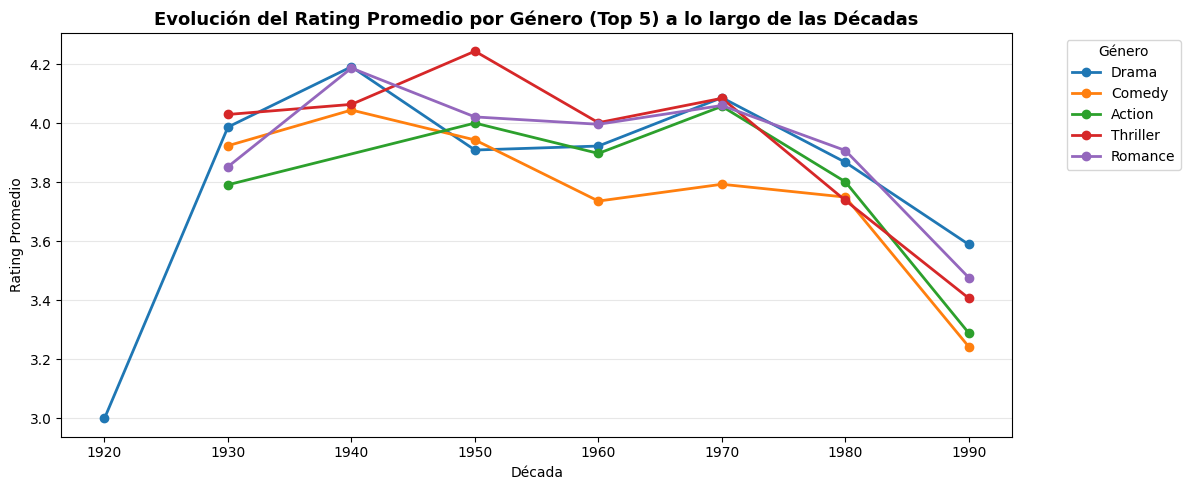

In [12]:
# ── 2.4 Evolución de géneros por década ──────────────────────────────────────
genre_decade = []
for g in genre_cols:
    if g in df.columns:
        temp = df[df[g] == 1].groupby('decade').agg(
            avg_rating=('rating', 'mean'),
            count=('rating', 'count')
        ).reset_index()
        temp['genre'] = g
        genre_decade.append(temp)

genre_decade_df = pd.concat(genre_decade, ignore_index=True)

# Mostrar los 5 géneros más populares a lo largo del tiempo
top5_genres = genre_df.head(5)['genre'].tolist()
gd_top5 = genre_decade_df[genre_decade_df['genre'].isin(top5_genres)]

plt.figure(figsize=(12, 5))
for genre in top5_genres:
    subset = gd_top5[gd_top5['genre'] == genre]
    plt.plot(subset['decade'].astype(str), subset['avg_rating'], marker='o', linewidth=2, label=genre)

plt.title('Evolución del Rating Promedio por Género (Top 5) a lo largo de las Décadas', fontsize=13, fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Rating Promedio')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Insights y Conclusiones

### Análisis Temporal (Evolución por Década)

1. **Concentración en los 90s**: La gran mayoría de las películas del dataset pertenecen a la década de 1990, lo cual es esperable dado que MovieLens 100K recopila datos de usuarios activos entre 1997-1998. Las películas más recientes dominan tanto en cantidad como en número de ratings.

2. **Películas antiguas mejor valoradas**: Las películas de décadas anteriores (1920s-1960s) tienden a tener ratings promedio más altos. Esto sugiere un **sesgo de supervivencia**: solo los clásicos más reconocidos de esas épocas están presentes en el catálogo, y los usuarios que las califican suelen ser cinéfilos con aprecio por el cine clásico.

3. **Efecto de volumen vs. calidad**: Las décadas con más películas (80s-90s) muestran ratings promedio más cercanos a la media global (~3.5), lo que indica mayor diversidad en calidad. En contraste, décadas con pocas películas muestran promedios más extremos (altos o bajos).

---

### Análisis por Género

4. **Drama domina**: Drama es el género con más películas y más ratings por un amplio margen, seguido de Comedy y Action. Esto refleja la estructura natural de la industria cinematográfica.

5. **Film-Noir y War: calidad sobre cantidad**: Géneros de nicho como Film-Noir y War tienen los ratings promedio más altos a pesar de tener pocas películas. Los usuarios que buscan estos géneros son más selectivos y aprecian más lo que encuentran.

6. **Horror y Fantasy: los peor valorados**: Estos géneros aparecen consistentemente con los ratings más bajos, posiblemente por la alta proporción de producciones de bajo presupuesto en estas categorías.

7. **Co-ocurrencia de géneros**: Drama se combina frecuentemente con Romance, Thriller y Comedy. Action se empareja con Adventure y Thriller. Esto revela los "paquetes" de géneros habituales en la industria.

8. **Evolución temporal de géneros**: Los géneros populares (Drama, Comedy) mantienen ratings relativamente estables a lo largo de las décadas, mientras que géneros de nicho muestran mayor variabilidad.

---

### Conclusión General

El dataset MovieLens 100K refleja los patrones de consumo cinematográfico de finales de los 90s: predominan los dramas y comedias recientes, pero los clásicos de décadas anteriores reciben valoraciones superiores. La popularidad de un género no garantiza alta calificación — los géneros de nicho con audiencias especializadas tienden a obtener mejores valoraciones que los géneros mainstream de alto volumen.